# Benchmark: Serial vs Parallel Iterative SLSQP

Compares the current serial `iterative_with_jacobians2` implementation against
the parallelized `iterative_parallel` which batches non-overlapping windows
into a `ProcessPoolExecutor`.

In [1]:
import time
import numpy as np
import modules.laplacian as laplacian
from modules.dvfopt import iterative_with_jacobians2, jacobian_det2D
from modules.dvfopt_parallel import iterative_parallel
from modules.dvfviz import plot_deformations, plot_initial_deformation

## Helper: benchmark runner

In [2]:
def benchmark(deformation_i, label, msample=None, fsample=None, n_runs=1, **kwargs):
    """Run serial and parallel, print comparison table."""
    print(f"\n{'='*70}")
    print(f"  BENCHMARK: {label}")
    print(f"  Grid: {deformation_i.shape[-2]}x{deformation_i.shape[-1]}")
    jac_init = jacobian_det2D(np.stack([deformation_i[-2], deformation_i[-1]]))
    n_neg = int((jac_init <= 0).sum())
    print(f"  Initial neg-Jdet pixels: {n_neg}")
    print(f"{'='*70}\n")

    results = {}

    for name, func in [("Serial", iterative_with_jacobians2),
                        ("Parallel", iterative_parallel)]:
        times = []
        for run in range(n_runs):
            t0 = time.perf_counter()
            phi = func(deformation_i.copy(), verbose=0, **kwargs)
            elapsed = time.perf_counter() - t0
            times.append(elapsed)

        jac_final = jacobian_det2D(phi)
        final_neg = int((jac_final <= 0).sum())
        final_min = float(jac_final.min())
        l2_err = float(np.sqrt(np.sum((phi - np.stack([deformation_i[-2, 0], deformation_i[-1, 0]]))**2)))

        avg_t = np.mean(times)
        std_t = np.std(times) if n_runs > 1 else 0.0

        results[name] = {
            "time_avg": avg_t,
            "time_std": std_t,
            "times": times,
            "final_neg": final_neg,
            "final_min": final_min,
            "l2_err": l2_err,
            "phi": phi,
        }

        print(f"  {name:10s}:  {avg_t:8.2f}s (±{std_t:.2f}s)  |  "
              f"neg_jdet={final_neg}  min_jdet={final_min:+.6f}  L2={l2_err:.4f}")

    # Speedup
    if results["Serial"]["time_avg"] > 0:
        speedup = results["Serial"]["time_avg"] / results["Parallel"]["time_avg"]
        print(f"\n  Speedup: {speedup:.2f}x")

    print()
    return results

---
## Test Case 1: 20×40 grid, 8 correspondences (from notebook)

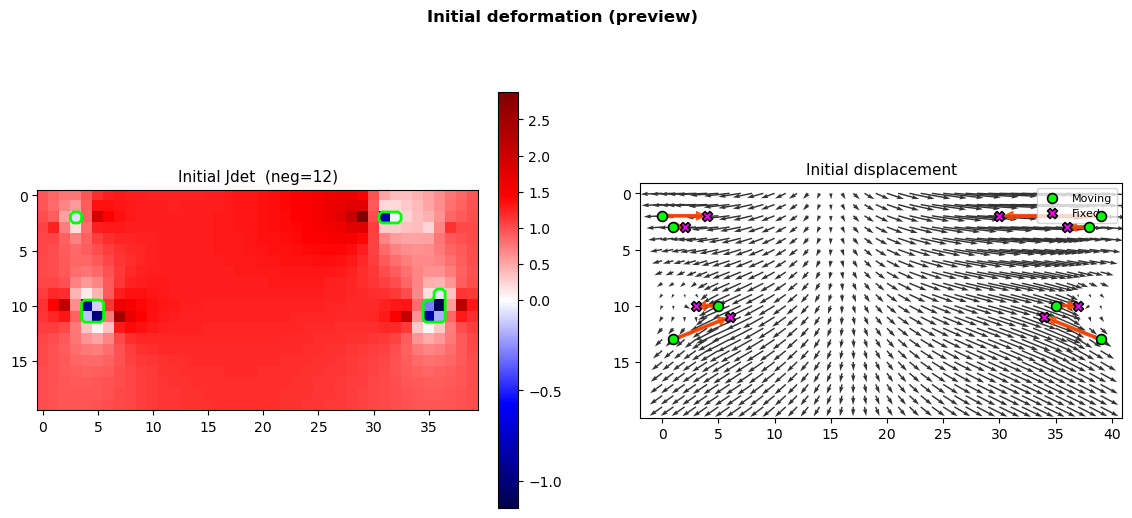


  BENCHMARK: 20x40, 8 correspondences
  Grid: 20x40
  Initial neg-Jdet pixels: 12

  Serial    :     45.87s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=2.0251
  Parallel  :     20.43s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=2.0251

  Speedup: 2.25x



In [3]:
msample = np.array([
    [0, 2, 0],
    [0, 3, 1],
    [0, 10, 5],
    [0, 13, 1],
    [0, 2, 39],
    [0, 3, 38],
    [0, 10, 35],
    [0, 13, 39],
])
fsample = np.array([
    [0, 2, 4],
    [0, 3, 2],
    [0, 10, 3],
    [0, 11, 6],
    [0, 2, 30],
    [0, 3, 36],
    [0, 10, 37],
    [0, 11, 34]
])

fixed_sample = np.zeros((1, 20, 40))
deformation_i, *_ = laplacian.sliceToSlice3DLaplacian(fixed_sample, msample, fsample)
plot_initial_deformation(deformation_i, msample, fsample)

r1 = benchmark(deformation_i, "20x40, 8 correspondences")

## Test Case 2: 10×10 crossing

In [4]:
msample = np.array([
    [0, 2, 2],
    [0, 3, 5],
])
fsample = np.array([
    [0, 2, 5],
    [0, 3, 2],
])

fixed_sample = np.zeros((1, 10, 10))
deformation_i, *_ = laplacian.sliceToSlice3DLaplacian(fixed_sample, msample, fsample)

r2 = benchmark(deformation_i, "10x10, 2 crossing")


  BENCHMARK: 10x10, 2 crossing
  Grid: 10x10
  Initial neg-Jdet pixels: 4

  Serial    :      7.01s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=1.1844
  Parallel  :      6.78s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=1.1844

  Speedup: 1.03x



## Test Case 3: 20×40, 20 correspondences (dense)

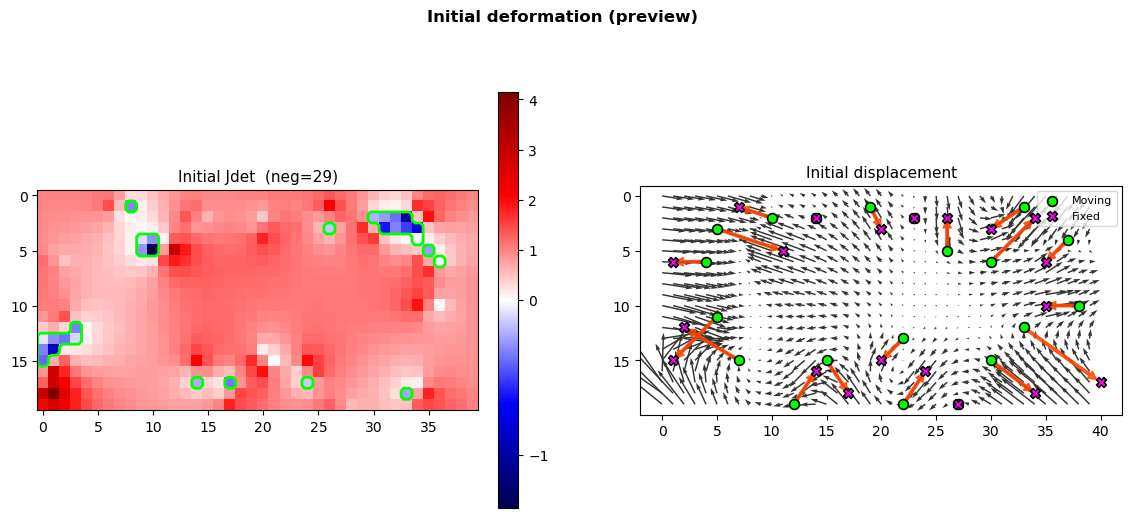


  BENCHMARK: 20x40, 20 correspondences
  Grid: 20x40
  Initial neg-Jdet pixels: 29



In [ ]:
msample = np.array([
    [0, 2, 10],
    [0, 3, 5],
    [0, 6, 4],
    [0, 11, 5],
    [0, 15, 7],
    [0, 19, 12],
    [0, 15, 15],
    [0, 13, 22],
    [0, 19, 22],
    [0, 19, 27],
    [0, 15, 30],
    [0, 12, 33],
    [0, 10, 38],
    [0, 4, 37],
    [0, 6, 30],
    [0, 1, 33],
    [0, 5, 26],
    [0, 2, 23],
    [0, 1, 19],
    [0, 2, 14],
])
fsample = np.array([
    [0, 1, 7],
    [0, 5, 11],
    [0, 6, 1],
    [0, 15, 1],
    [0, 12, 2],
    [0, 16, 14],
    [0, 18, 17],
    [0, 15, 20],
    [0, 16, 24],
    [0, 19, 27],
    [0, 18, 34],
    [0, 17, 40],
    [0, 10, 35],
    [0, 6, 35],
    [0, 2, 34],
    [0, 3, 30],
    [0, 2, 26],
    [0, 2, 23],
    [0, 3, 20],
    [0, 2, 14],
])

fixed_sample = np.zeros((1, 20, 40))
deformation_i, *_ = laplacian.sliceToSlice3DLaplacian(fixed_sample, msample, fsample)
plot_initial_deformation(deformation_i, msample, fsample)

r3 = benchmark(deformation_i, "20x40, 20 correspondences")

## Test Case 3b: 320×456, 20 correspondences (large, scattered neg-Jdet spots)

In [ ]:
# 320x456 grid with ~20 correspondences scattered around the image.
# Pairs are placed so displacement vectors cross/oppose locally,
# creating isolated spots of negative Jacobian determinants.

msample = np.array([
    # top-left cluster
    [0,  25,  30],
    [0,  30,  45],
    # top-right cluster
    [0,  20, 400],
    [0,  28, 410],
    # upper-middle — crossing pair
    [0,  60, 200],
    [0,  65, 215],
    # left side
    [0, 110,  25],
    [0, 120,  40],
    # centre cluster
    [0, 150, 220],
    [0, 155, 230],
    [0, 160, 210],
    # right side
    [0, 140, 420],
    [0, 150, 430],
    # lower-left
    [0, 240,  50],
    [0, 248,  60],
    # lower-centre
    [0, 260, 250],
    [0, 270, 260],
    # bottom-right cluster
    [0, 300, 380],
    [0, 305, 395],
    [0, 310, 410],
])

fsample = np.array([
    # top-left cluster — cross / compress
    [0,  30,  45],
    [0,  25,  30],
    # top-right cluster — cross
    [0,  28, 415],
    [0,  20, 395],
    # upper-middle — crossing pair
    [0,  65, 215],
    [0,  60, 195],
    # left side — opposing
    [0, 120,  40],
    [0, 110,  20],
    # centre cluster — 3-way crossing
    [0, 158, 235],
    [0, 148, 215],
    [0, 165, 225],
    # right side — cross
    [0, 150, 435],
    [0, 140, 415],
    # lower-left — cross
    [0, 250,  65],
    [0, 238,  45],
    # lower-centre — opposing
    [0, 272, 265],
    [0, 258, 245],
    # bottom-right cluster — 3 crossing
    [0, 308, 400],
    [0, 298, 380],
    [0, 315, 400],
])

fixed_sample = np.zeros((1, 320, 456))
deformation_i, *_ = laplacian.sliceToSlice3DLaplacian(fixed_sample, msample, fsample)
plot_initial_deformation(deformation_i, msample, fsample)

r3b = benchmark(deformation_i, "320x456, 20 correspondences")

## Test Case 4: Real data — 64×91 slice

In [ ]:
import os

real_path = "experiments/02b_64x91_slice200.npy"
if os.path.exists(real_path):
    deformation_i = np.load(real_path)
    plot_initial_deformation(deformation_i)
    r4 = benchmark(deformation_i, "64x91 real slice 200")
else:
    print(f"Skipping — {real_path} not found")

Skipping — experiments/02b_64x91_slice200.npy not found


## Test Case 5: Saved .npy test cases

In [ ]:
npy_cases = [
    ("experiments/03a_10x10_opposite.npy", "10x10 opposites"),
    ("experiments/03b_10x10_crossing.npy", "10x10 crossing"),
    ("experiments/03c_20x20_opposite.npy", "20x20 opposites"),
    ("experiments/03d_20x20_crossing.npy", "20x20 crossing"),
]

npy_results = {}
for path, label in npy_cases:
    if os.path.exists(path):
        deformation_i = np.load(path)
        npy_results[label] = benchmark(deformation_i, label)
    else:
        print(f"Skipping — {path} not found")

Skipping — experiments/03a_10x10_opposite.npy not found
Skipping — experiments/03b_10x10_crossing.npy not found
Skipping — experiments/03c_20x20_opposite.npy not found
Skipping — experiments/03d_20x20_crossing.npy not found


---
## Summary table

In [ ]:
all_results = {}
for name, r in [("20x40 (8 corr)", r1),
                ("10x10 crossing", r2),
                ("20x40 (20 corr)", r3),
                ("320x456 (20 corr)", r3b)]:
    all_results[name] = r

if 'r4' in dir():
    all_results["64x91 real"] = r4

for name, r in npy_results.items():
    all_results[name] = r

print(f"{'Test Case':<22s}  {'Serial (s)':>12s}  {'Parallel (s)':>14s}  {'Speedup':>8s}  {'S neg':>6s}  {'P neg':>6s}  {'S L2':>10s}  {'P L2':>10s}")
print("-" * 110)
for label, r in all_results.items():
    s = r["Serial"]
    p = r["Parallel"]
    speedup = s["time_avg"] / p["time_avg"] if p["time_avg"] > 0 else float('inf')
    print(f"{label:<22s}  {s['time_avg']:12.2f}  {p['time_avg']:14.2f}  {speedup:7.2f}x  "
          f"{s['final_neg']:6d}  {p['final_neg']:6d}  {s['l2_err']:10.4f}  {p['l2_err']:10.4f}")

Test Case                 Serial (s)    Parallel (s)   Speedup   S neg   P neg        S L2        P L2
--------------------------------------------------------------------------------------------------------------
20x40 (8 corr)                 39.44           21.09     1.87x       0       0      2.0251      2.0251
10x10 crossing                  6.01            5.56     1.08x       0       0      1.1844      1.1844
20x40 (20 corr)               160.85           52.35     3.07x       0       0      2.9478      2.9415


## Visual comparison (last test case)

In [ ]:
# Pick the last available results to visualise
last_label = list(all_results.keys())[-1]
last_r = all_results[last_label]

# Reload the deformation for the last case to show side-by-side
print(f"Visual comparison for: {last_label}")
print(f"\nSerial result:")
print(f"  neg_jdet={last_r['Serial']['final_neg']}  min_jdet={last_r['Serial']['final_min']:+.6f}  L2={last_r['Serial']['l2_err']:.4f}")
print(f"\nParallel result:")
print(f"  neg_jdet={last_r['Parallel']['final_neg']}  min_jdet={last_r['Parallel']['final_min']:+.6f}  L2={last_r['Parallel']['l2_err']:.4f}")

# Difference between serial and parallel phi
diff = np.abs(last_r['Serial']['phi'] - last_r['Parallel']['phi'])
print(f"\nMax |phi_serial - phi_parallel|: {diff.max():.6f}")
print(f"Mean |phi_serial - phi_parallel|: {diff.mean():.6f}")

Visual comparison for: 20x40 (20 corr)

Serial result:
  neg_jdet=0  min_jdet=+0.010000  L2=2.9478

Parallel result:
  neg_jdet=0  min_jdet=+0.010000  L2=2.9415

Max |phi_serial - phi_parallel|: 0.151110
Mean |phi_serial - phi_parallel|: 0.000300
